Véc-tơ trung bình mẫu (x_bar):
[1906.1        1749.53333333 1509.13333333 1724.96666667]

Giá trị tới hạn Chi-Square (p=4, alpha=0.005): 14.86

CÁC QUAN SÁT LÀ GIÁ TRỊ NGOẠI BIÊN ĐA BIẾN:
    QuanSat      x1      x2      x3      x4        z1        z2       z3  \
15       16  1954.0  2149.0  1180.0  1281.0  0.147391  1.253793 -1.08561   

          z4         d2  
15 -1.375176  16.847407  


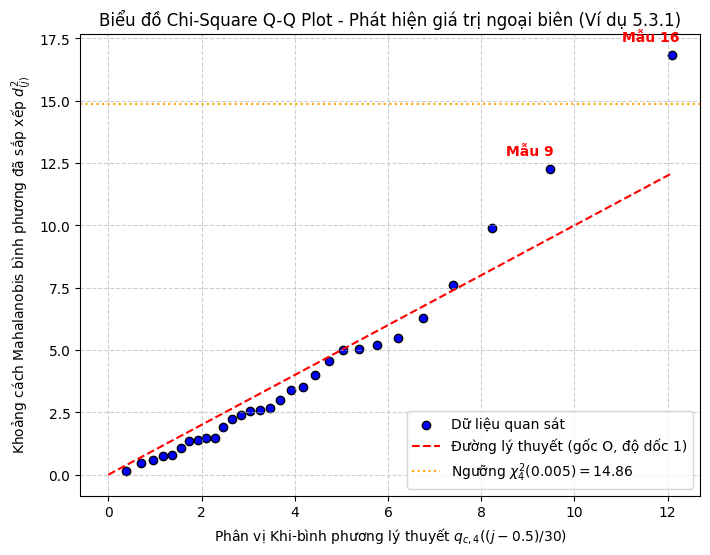

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

data = np.array([
    [1889, 1651, 1561, 1778],
    [2403, 2048, 2087, 2197],
    [2119, 1700, 1815, 2222],
    [1645, 1627, 1110, 1533],
    [1976, 1916, 1614, 1883],
    [1712, 1712, 1439, 1546],
    [1943, 1685, 1271, 1671],
    [2104, 1820, 1717, 1874],
    [2983, 2794, 2412, 2581],
    [1745, 1600, 1384, 1508],
    [1710, 1591, 1518, 1667],
    [2046, 1907, 1627, 1898],
    [1840, 1841, 1595, 1741],
    [1867, 1685, 1493, 1678],
    [1859, 1649, 1389, 1714],
    [1954, 2149, 1180, 1281],
    [1325, 1170, 1002, 1176],
    [1419, 1371, 1252, 1308],
    [1828, 1634, 1602, 1755],
    [1725, 1594, 1313, 1646],
    [2276, 2189, 1547, 2111],
    [1899, 1614, 1422, 1477],
    [1633, 1513, 1290, 1516],
    [2061, 1867, 1646, 2037],
    [1856, 1493, 1356, 1533],
    [1727, 1412, 1238, 1469],
    [2168, 1896, 1701, 1834],
    [1655, 1675, 1414, 1597],
    [2326, 2301, 2065, 2234],
    [1490, 1382, 1214, 1284]
], dtype=float)

n, p = data.shape

x_bar = np.mean(data, axis=0)
S = np.cov(data, rowvar=False, ddof=1)
S_inv = np.linalg.inv(S)
std_devs = np.sqrt(np.diag(S))

Z = (data - x_bar) / std_devs

d2 = np.zeros(n)
for j in range(n):
    diff = data[j] - x_bar
    d2[j] = diff.T @ S_inv @ diff

alpha = 0.005
critical_value = stats.chi2.ppf(1 - alpha, df=p)

df_results = pd.DataFrame({
    'QuanSat': np.arange(1, n + 1),
    'x1': data[:, 0], 'x2': data[:, 1], 'x3': data[:, 2], 'x4': data[:, 3],
    'z1': Z[:, 0], 'z2': Z[:, 1], 'z3': Z[:, 2], 'z4': Z[:, 3],
    'd2': d2,
    'La_NgoaiBien': d2 > critical_value
})

print("="*60)
print(f"Véc-tơ trung bình mẫu (x_bar):\n{x_bar}")
print(f"\nGiá trị tới hạn Chi-Square (p={p}, alpha={alpha}): {critical_value:.2f}")
print("="*60)

print("\nCÁC QUAN SÁT LÀ GIÁ TRỊ NGOẠI BIÊN ĐA BIẾN:")
outliers = df_results[df_results['La_NgoaiBien']]
print(outliers[['QuanSat', 'x1', 'x2', 'x3', 'x4', 'z1', 'z2', 'z3', 'z4', 'd2']])

d2_sorted = np.sort(d2)
probabilities = (np.arange(1, n + 1) - 0.5) / n
chi2_quantiles = stats.chi2.ppf(probabilities, df=p)

plt.figure(figsize=(8, 6))
plt.scatter(chi2_quantiles, d2_sorted, color='blue', edgecolor='k', label='Dữ liệu quan sát')
plt.plot([0, max(chi2_quantiles)], [0, max(chi2_quantiles)], 'r--', label='Đường lý thuyết (gốc O, độ dốc 1)')
plt.axhline(y=critical_value, color='orange', linestyle=':', label=f'Ngưỡng $\chi_4^2(0.005) = {critical_value:.2f}$')

for i, orig_idx in enumerate(np.argsort(d2)):
    specimen_num = orig_idx + 1
    if specimen_num in [9, 16]:
        plt.annotate(f'Mẫu {specimen_num}', 
                     (chi2_quantiles[i], d2_sorted[i]),
                     textcoords="offset points", 
                     xytext=(-15, 10), 
                     ha='center',
                     fontweight='bold',
                     color='red')

plt.title('Biểu đồ Chi-Square Q-Q Plot - Phát hiện giá trị ngoại biên (Ví dụ 5.3.1)')
plt.xlabel('Phân vị Khi-bình phương lý thuyết $q_{c,4}((j-0.5)/30)$')
plt.ylabel('Khoảng cách Mahalanobis bình phương đã sắp xếp $d_{(j)}^2$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()